# Clustering
## This code aims to group songs into distinct mood categories using a unsupervised clustering model based on audio features like valence, energy, dancaeability, acousticness, and tempo.
Valence → emotional positivity

    High = happy, cheerful

    Low = sad, gloomy

Energy → intensity and loudness

    High = energetic, powerful

    Low = calm, mellow

Danceability → how rhythmically suitable a track is for dancing

    High = groovy, poppy

    Low = stiff, slow, abstract

Acousticness → how acoustic (vs. electronic) a track is

    High = more natural, mellow, often singer-songwriter or ambient

    Low = electronic, produced

Tempo → speed in beats per minute

    High = fast-paced

    Low = slow-paced



Features Excluded:

These aren’t related to how a song feels emotionally:

track_id, track_name, artists, album_name	Metadata - not mood-relevant

popularity - Reflects marketing, not emotional tone

explicit - Censorship flag, not a mood indicator

key, mode, time_signature - Theoretically related to mood in music theory but not strongly predictive in ML unless you're doing advanced modeling

track_genre - Too broad or categorical; use only if doing supervised mood prediction

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt  
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA  
import joblib

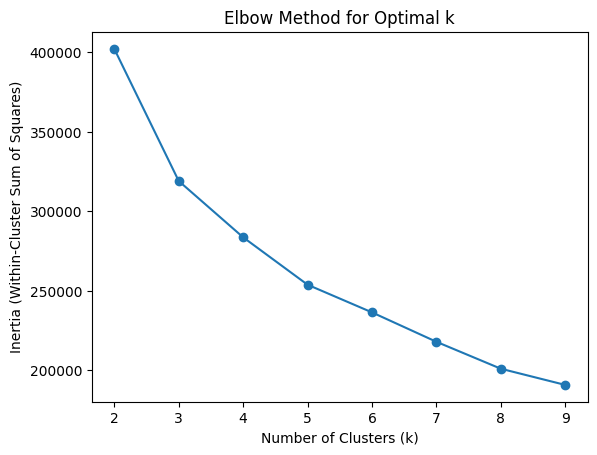

In [2]:
# Load dataset
df = pd.read_csv("cleaned_dataset.csv")  # Use your actual CSV

scaler = StandardScaler()
x_scaled = scaler.fit_transform(df[['valence', 'energy', 'danceability', 'acousticness', 'tempo']])


inertia = []
k_values = range(2, 10)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(x_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(k_values, inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.title('Elbow Method for Optimal k')
plt.show()

In [3]:
optimal_k = 4  # change this to the value from your elbow
kmeans = KMeans(n_clusters=optimal_k, random_state=0)
df['cluster'] = kmeans.fit_predict(x_scaled)

In [4]:
centers = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),  # convert back to original scale
    columns=df[['valence', 'energy', 'danceability', 'acousticness', 'tempo']].columns
)
print(centers)

    valence    energy  danceability  acousticness       tempo
0  0.455700  0.801775      0.462359      0.124934  162.540803
1  0.293845  0.750938      0.545327      0.096755  110.723308
2  0.316143  0.303751      0.467885      0.784430  109.577168
3  0.723837  0.707322      0.707193      0.253116  117.204983


In [5]:
# Auto-generate mood labels based on cluster center traits
def auto_label_cluster(center):
    valence, energy, danceability, acousticness, tempo = center

    mood_traits = []

    if valence > 0.5:
        mood_traits.append("Happy")
    else:
        mood_traits.append("Sad/Serious")

    if energy > 0.7:
        mood_traits.append("Energetic")
    elif energy < 0.4:
        mood_traits.append("Calm")
    else:
        mood_traits.append("Moderate Energy")

    if danceability > 0.6:
        mood_traits.append("Danceable")
    else:
        mood_traits.append("Laid-back")

    if acousticness > 0.5:
        mood_traits.append("Acoustic")
    else:
        mood_traits.append("Electronic")

    if tempo > 120:
        mood_traits.append("Fast Tempo")
    else:
        mood_traits.append("Slow Tempo")

    return ", ".join(mood_traits)

# Auto-label all clusters
cluster_names = {}
for idx, center in centers.iterrows():
    mood_name = auto_label_cluster(center)
    cluster_names[idx] = mood_name
    print(f"Cluster {idx}: {mood_name}")

# Update df with auto-generated mood names
df['mood'] = df['cluster'].map(cluster_names)

Cluster 0: Sad/Serious, Energetic, Laid-back, Electronic, Fast Tempo
Cluster 1: Sad/Serious, Energetic, Laid-back, Electronic, Slow Tempo
Cluster 2: Sad/Serious, Calm, Laid-back, Acoustic, Slow Tempo
Cluster 3: Happy, Energetic, Danceable, Electronic, Slow Tempo


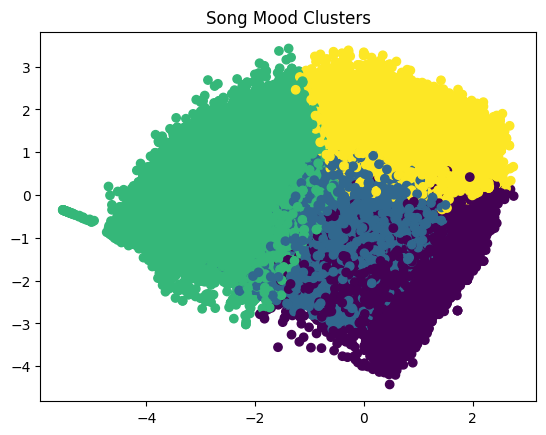

In [6]:
pca = PCA(n_components=2)
X_2D = pca.fit_transform(x_scaled)

plt.scatter(X_2D[:, 0], X_2D[:, 1], c=df['cluster'], cmap='viridis')
plt.title("Song Mood Clusters")
plt.show()

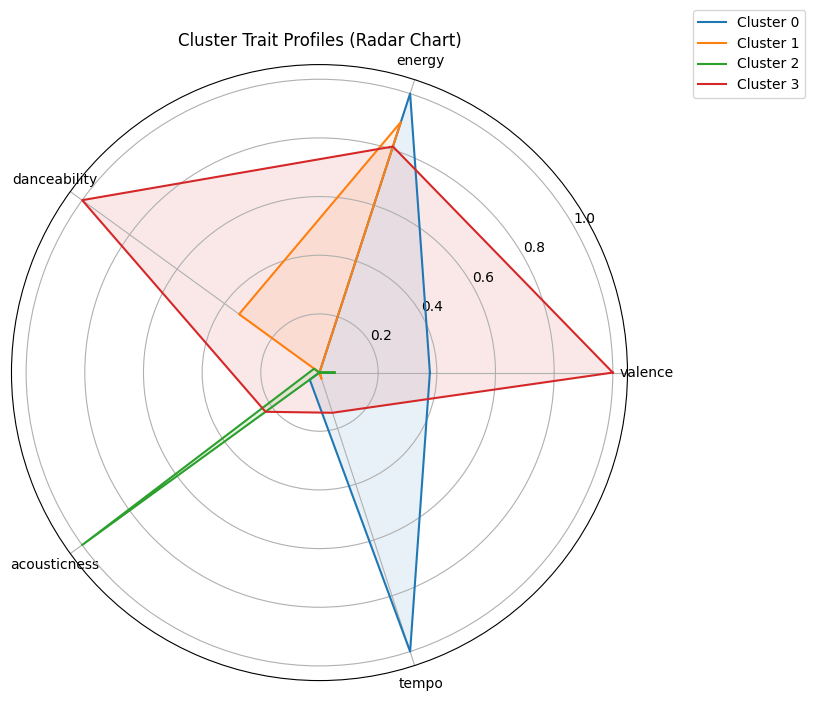

In [7]:
# Radar chart plotting function
def plot_radar_chart(centers_df):
    categories = list(centers_df.columns)
    num_vars = len(categories)

    # Compute angle for each category axis
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]  # repeat the first angle to close the loop

    # Initialize the radar plot
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    # Plot each cluster's profile
    for idx, row in centers_df.iterrows():
        values = row.tolist()
        values += values[:1]  # repeat first value to close the loop
        ax.plot(angles, values, label=f"Cluster {idx}")
        ax.fill(angles, values, alpha=0.1)

    # Draw category labels
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories)

    # Set grid and legend
    ax.set_rlabel_position(30)
    plt.title('Cluster Trait Profiles (Radar Chart)')
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.show()

# Normalize centers to 0-1 range for Radar Chart visualization
normalized_centers = (centers - centers.min()) / (centers.max() - centers.min())

# Plot normalized radar chart
plot_radar_chart(normalized_centers)

In [8]:
# Split original dataset into Train and Test (e.g., 80% Train, 20% Test)
X_train, X_test = train_test_split(df[['valence', 'energy', 'danceability', 'acousticness', 'tempo']], 
                                   test_size=0.2, random_state=42)

# Scale Train and Test data separately to avoid data leakage
scaler_train = StandardScaler()
X_train_scaled = scaler_train.fit_transform(X_train)

scaler_test = StandardScaler()
X_test_scaled = scaler_test.fit_transform(X_test)

# Train KMeans on Training Data
kmeans_train = KMeans(n_clusters=optimal_k, random_state=0)
kmeans_train.fit(X_train_scaled)

# Predict clusters for Test Data
kmeans_test = KMeans(n_clusters=optimal_k, random_state=0)
kmeans_test.fit(X_test_scaled)

# Evaluate with Silhouette Score on Train and Test
silhouette_train = silhouette_score(X_train_scaled, kmeans_train.labels_)
silhouette_test = silhouette_score(X_test_scaled, kmeans_test.labels_)

print(f"Silhouette Score (Train): {silhouette_train}")
print(f"Silhouette Score (Test): {silhouette_test}")

Silhouette Score (Train): 0.22070441439412256
Silhouette Score (Test): 0.22366290704634326


In [9]:
joblib.dump(kmeans, 'song_mood_kmeans.joblib')
joblib.dump(scaler, 'scaler.joblib')

['scaler.joblib']